# stepzero — Quickstart

A 5-minute tour of all six tasks.

In [1]:
import stepzero as sz
print(sz.__version__)

0.1.0


## 1. Classification — Iris

In [2]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True, as_frame=True)

result = sz.classify(X, y)
print(result)
print()
print(result.headroom)


ClassifyResult(best='logistic', accuracy=0.953, headroom='Low')

[Low] Score of 0.95 with low variance (±0.045). The simple baseline is already performing well. Trying a gradient boosted tree (e.g., XGBoost or LightGBM) is unlikely to offer a meaningful improvement.


In [3]:
# All models compared
for s in result.scores:
    print(f"  {s.name:<15} {s.metric} = {s.score:.3f}")


  logistic        accuracy = 0.953
  tree            accuracy = 0.947
  naive_bayes     accuracy = 0.947


<Axes: title={'center': 'Feature importance'}>

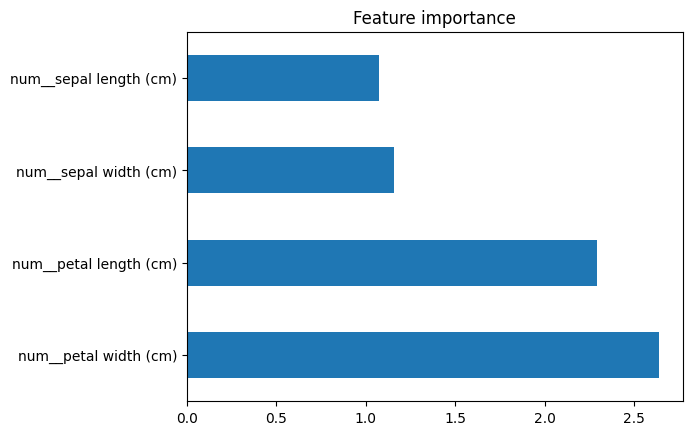

In [4]:
# Feature importance from the winning model
result.feature_importance.plot(kind="barh", title="Feature importance")


## 2. Regression — Diabetes

In [5]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True, as_frame=True)

result = sz.regress(X, y)
print(result)
print()
print(result.headroom)


RegressResult(best='ridge', root mean squared error=54.827, headroom='Low')

[Low] Score of 54.8271 with low variance (±2.5636). The simple baseline is already performing well. Trying a gradient boosted tree (e.g., XGBoost or LightGBM) is unlikely to offer a meaningful improvement.


<Axes: title={'center': 'Feature importance (normalized)'}>

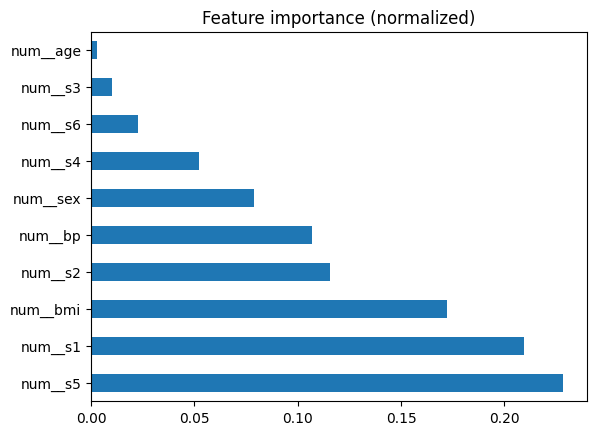

In [6]:
result.feature_importance.plot(kind="barh", title="Feature importance (normalized)")


## 3. Forecasting — Synthetic trend + seasonality

<Axes: title={'center': 'Training series'}>

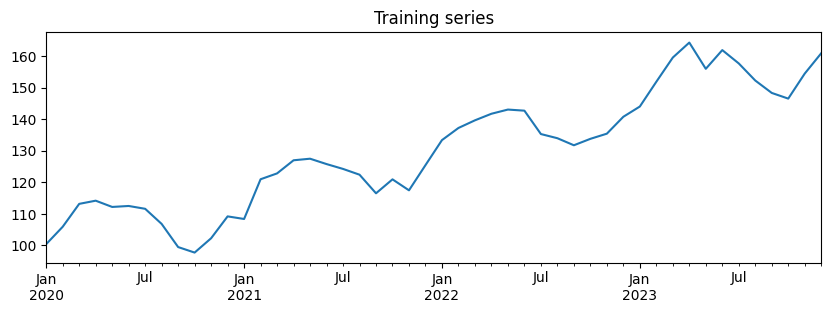

In [7]:
import numpy as np
import pandas as pd

# 4 years of monthly data: upward trend + yearly seasonality
idx = pd.date_range("2020-01", periods=48, freq="ME")
trend = np.linspace(100, 160, 48)
seasonal = 10 * np.sin(2 * np.pi * np.arange(48) / 12)
noise = np.random.default_rng(0).normal(0, 3, 48)
ts = pd.Series(trend + seasonal + noise, index=idx, name="value")

ts.plot(title="Training series", figsize=(10, 3))


In [8]:
result = sz.forecast(ts, horizon=12)
print(result)
print()
print(result.headroom)


ForecastResult(best='linear_trend', mae=11.178, horizon=12, headroom='Medium')

[Medium] Score of 11.1777 (±6.3607). Moderate headroom remains. Trying ARIMA, Prophet, or a neural forecasting model may yield a moderate improvement.


Text(0.5, 1.0, 'stepzero forecast — 12-month horizon')

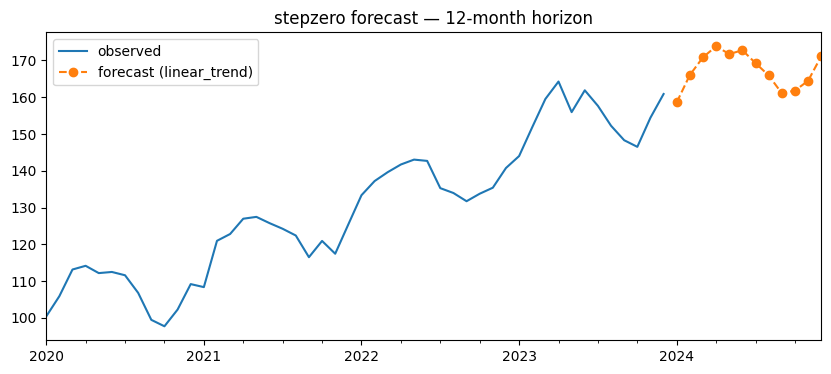

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ts.plot(ax=ax, label="observed")
result.forecast.plot(ax=ax, label=f"forecast ({result.best_model_name})", linestyle="--", marker="o")
ax.legend()
ax.set_title("stepzero forecast — 12-month horizon")


## 4. Anomaly detection — Synthetic sensor data

In [10]:
rng = np.random.default_rng(42)
sensor = pd.Series(rng.normal(0, 1, 200), name="sensor")
sensor.iloc[[20, 80, 140, 180]] = [6, -7, 8, -6]  # inject 4 spikes

result = sz.detect_anomalies(sensor)
print(result)
print()
print(result.headroom)


AnomalyResult(method='iqr', anomalies=10 (5.0%), headroom='Low')

[Low] Both detection methods agree on 100% of flagged points. The anomaly pattern is clear. Isolation Forest or a learned autoencoder is unlikely to improve substantially.


Text(0.5, 1.0, 'Anomaly detection (iqr, threshold=1.50)')

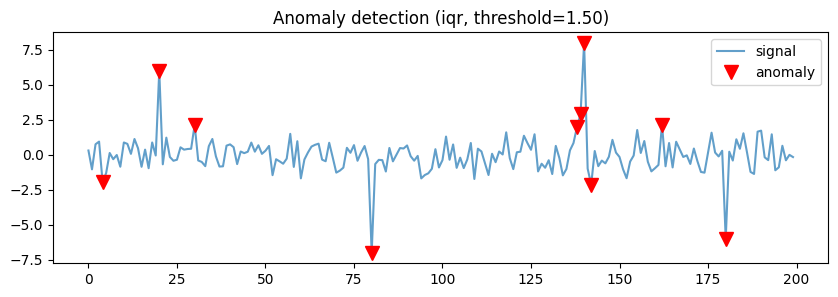

In [11]:
fig, ax = plt.subplots(figsize=(10, 3))
sensor.plot(ax=ax, label="signal", alpha=0.7)
sensor[result.anomalies].plot(ax=ax, style="rv", label="anomaly", markersize=10)
ax.legend()
ax.set_title(f"Anomaly detection ({result.method}, threshold={result.threshold:.2f})")


## 5. Text classification — 20 Newsgroups (2 categories)

In [12]:
from sklearn.datasets import fetch_20newsgroups

cats = ["sci.space", "talk.politics.guns"]
train = fetch_20newsgroups(subset="train", categories=cats)

result = sz.text_classify(train.data, train.target, cv=3)
print(result)
print()
print(result.headroom)


TextClassifyResult(best='tfidf_naive_bayes', accuracy=0.989, headroom='Low')

[Low] Score of 0.99 with low variance (±0.004). The simple baseline is already performing well. Trying a fine-tuned transformer (e.g., DistilBERT) is unlikely to offer a meaningful improvement.


In [13]:
# Top discriminative terms per class
for cls, terms in result.top_features_per_class.items():
    label = train.target_names[int(cls)]
    print(f"  {label}: {', '.join(terms[:8])}")


  sci.space: the, of, to, space, in, and, edu, is
  talk.politics.guns: the, to, of, and, in, that, you, edu


## 6. Clustering — make_blobs

In [14]:
from sklearn.datasets import make_blobs

X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=0)

result = sz.cluster(X_blobs, k_range=(2, 8))
print(result)
print()
print(result.headroom)


ClusterResult(best_k=4, silhouette=0.439, headroom='Medium')

[Medium] Silhouette score of 0.555 indicates moderate cluster separation. Try HDBSCAN or Gaussian Mixture Models for potentially better cluster structure.


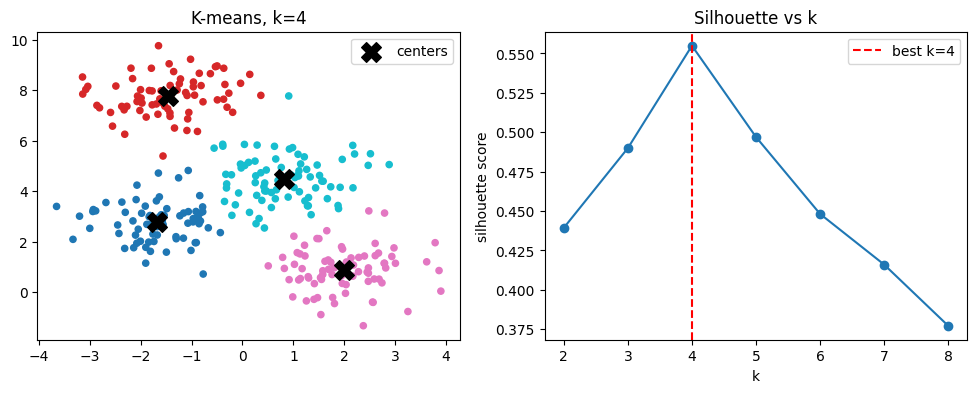

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: cluster assignments
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=result.labels, cmap="tab10", s=20)
axes[0].scatter(result.centers[:, 0], result.centers[:, 1], marker="X", s=200, c="black", label="centers")
axes[0].set_title(f"K-means, k={result.best_k}")
axes[0].legend()

# Right: silhouette score vs k
ks = [int(s.name.split("=")[1]) for s in result.scores]
sils = [s.score for s in result.scores]
axes[1].plot(ks, sils, marker="o")
axes[1].axvline(result.best_k, color="red", linestyle="--", label=f"best k={result.best_k}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette vs k")
axes[1].legend()
